In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from typing import TypedDict, Optional, List, Literal
from groq import Groq
import uuid

# ─ Groq Setup (Native SDK) ─
client = Groq(api_key="")
MODEL = "meta-llama/llama-4-scout-17b-16e-instruct"

def call_groq(prompt: str, max_completion_tokens: int = 500) -> str:
    """Call Groq LLM using native SDK"""
    try:
        message = client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            max_completion_tokens=max_completion_tokens,
            temperature=0.7,
            top_p=1,
            stop=None
        )
        return message.choices[0].message.content or "[No response]"
    except Exception as e:
        print(f"⚠️  Groq error: {str(e)[:100]}")
        return "[Error - mock response]"

# ─ State ─
class WorkflowState(TypedDict):
    session_id: str
    workspace_id: str
    user_id: str
    request: str
    template: Optional[Literal["social", "blog", "image", "research"]]
    clarification: List[dict]
    context: dict
    retrieved_docs: List[str]
    outline: Optional[str]
    draft: Optional[str]
    images: List[dict]
    edits: Optional[str]
    approved: bool
    publish_status: str
    usage: dict
    error: Optional[str]

# ─ CORE NODES ─
def session_init(state: WorkflowState) -> WorkflowState:
    state["session_id"] = str(uuid.uuid4())[:8]
    state["workspace_id"] = "default"
    state["user_id"] = "user123"
    state["usage"] = {"tokens": 0, "cost": 0.0}
    print(f"📌 SESSION_INIT: {state['session_id']}")
    return state

def load_context(state: WorkflowState) -> WorkflowState:
    state["context"] = {
        "brand_voice": "Professional, innovative",
        "tone": "Friendly"
    }
    print("📂 LOAD_CONTEXT: ✅")
    return state

def classify_request(state: WorkflowState) -> WorkflowState:
    r = state["request"].lower()
    if any(w in r for w in ["tweet", "caption", "post", "social"]): state["template"] = "social"
    elif any(w in r for w in ["article", "blog", "write"]): state["template"] = "blog"
    elif any(w in r for w in ["image", "visual"]): state["template"] = "image"
    elif any(w in r for w in ["research", "report"]): state["template"] = "research"
    else: state["template"] = "social"
    print(f"🔍 CLASSIFY: {state['template'].upper()}")
    return state

def clarify(state: WorkflowState) -> Command:
    if state["template"] == "blog" and len(state["request"]) < 50:
        print("❓ CLARIFY: Need more info")
        return Command(goto="clarify_pause", update=state)
    print("✅ No clarification")
    return Command(goto="select_template", update=state)

def clarify_pause(state: WorkflowState) -> WorkflowState:
    print("⏸️  PAUSED at CLARIFY")
    return state

# ─ TEMPLATE NODES ─
def select_template(state: WorkflowState) -> WorkflowState:
    print(f"📋 SELECT: {state['template'].upper()}")
    return state

def execute_social(state: WorkflowState) -> WorkflowState:
    print("🟩 [SOCIAL]...")
    caption = call_groq(f"Social caption for: {state['request']}\nMax 280 chars", max_completion_tokens=200)
    state["draft"] = caption
    state["usage"]["tokens"] += 150
    print(f"  ✅ Done")
    return state

def execute_blog(state: WorkflowState) -> Command:
    print("🟦 [BLOG]...")
    outline = call_groq(f"Blog outline for: {state['request']}", max_completion_tokens=300)
    state["outline"] = outline
    state["usage"]["tokens"] += 200
    print(f"  ⏸️  Waiting for approval...")
    return Command(goto="blog_outline_pause", update=state)

def blog_outline_pause(state: WorkflowState) -> WorkflowState:
    print("⏸️  PAUSED at BLOG OUTLINE")
    return state

def execute_blog_continue(state: WorkflowState) -> WorkflowState:
    print("🟦 [BLOG] Resume...")
    draft = call_groq(f"Write blog from: {state['outline']}", max_completion_tokens=700)
    state["draft"] = draft
    state["usage"]["tokens"] += 400
    print(f"  ✅ Done")
    return state

def execute_image(state: WorkflowState) -> WorkflowState:
    print("🟨 [IMAGE]...")
    prompt = call_groq(f"Image prompt for: {state['request']}", max_completion_tokens=150)
    state["images"] = [{"url": "https://example.com/img.png", "prompt": prompt}]
    state["draft"] = f"Prompt: {prompt}"
    state["usage"]["tokens"] += 120
    print(f"  ✅ Done")
    return state

def execute_research(state: WorkflowState) -> WorkflowState:
    print("🟪 [RESEARCH]...")
    report = call_groq(f"Research: {state['request']}", max_completion_tokens=600)
    state["draft"] = report
    state["approved"] = True
    state["publish_status"] = "published"
    state["usage"]["tokens"] += 400
    print(f"  ✅ Auto-approved")
    return state

# ─ REVIEW & PUBLISH ─
def route_template(state: WorkflowState) -> str:
    templates = {"social": "execute_social", "blog": "execute_blog", "image": "execute_image", "research": "execute_research"}
    return templates.get(state["template"], "execute_social")

def review(state: WorkflowState) -> Command:
    print("🔍 REVIEW MODE")
    preview = (state["draft"][:100] if state["draft"] else "No draft")
    print(f"📄 {preview}...")
    print("⏸️  PAUSED — Waiting for approval...")
    return Command(goto="review_pause", update=state)

def review_pause(state: WorkflowState) -> WorkflowState:
    return state

def approve(state: WorkflowState) -> WorkflowState:
    state["approved"] = True
    print("✅ APPROVED")
    return state

def publish(state: WorkflowState) -> WorkflowState:
    print("📤 PUBLISH...")
    state["publish_status"] = "published"
    print("✅ Published")
    return state

def save(state: WorkflowState) -> WorkflowState:
    print("💾 SAVE...")
    print(f"✅ Session {state['session_id']} saved")
    return state

print("✅ Cell 1: All functions + Groq SDK loaded")

✅ Cell 1: All functions + Groq SDK loaded


In [ ]:
from groq import Groq
from langgraph.types import Command
import uuid
from datetime import datetime

# ─ Groq Config (Native SDK) ─
client = Groq(api_key="")
MODEL = "meta-llama/llama-4-scout-17b-16e-instruct"

def call_groq(prompt: str, max_completion_tokens: int = 500) -> str:
    """Call Groq LLM using native SDK"""
    try:
        message = client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            max_completion_tokens=max_completion_tokens,
            temperature=0.7,
            top_p=1,
            stop=None
        )
        return message.choices[0].message.content or "[No response]"
    except Exception as e:
        print(f"⚠️  Groq error: {str(e)[:100]}")
        return "[Error - mock response]"

# ─ CORE NODES ─

def session_init(state: WorkflowState) -> WorkflowState:
    state["session_id"] = str(uuid.uuid4())[:8]
    state["workspace_id"] = "default"
    state["user_id"] = "user123"
    state["usage"] = {"tokens": 0, "cost": 0.0}
    print(f"📌 SESSION_INIT: {state['session_id']}")
    return state

def load_context(state: WorkflowState) -> WorkflowState:
    state["context"] = {
        "brand_voice": "Professional, innovative",
        "tone": "Friendly",
        "history": [],
        "templates_used": []
    }
    print("📂 LOAD_CONTEXT: ✅")
    return state

def classify_request(state: WorkflowState) -> WorkflowState:
    r = state["request"].lower()
    
    if any(w in r for w in ["tweet", "caption", "post", "social", "instagram"]):
        state["template"] = "social"
    elif any(w in r for w in ["article", "blog", "write", "blog post"]):
        state["template"] = "blog"
    elif any(w in r for w in ["image", "visual", "design", "generate image"]):
        state["template"] = "image"
    elif any(w in r for w in ["research", "report", "analyze", "investigate"]):
        state["template"] = "research"
    else:
        state["template"] = "social"
    
    print(f"🔍 CLASSIFY_REQUEST: {state['template'].upper()}")
    return state

def clarify(state: WorkflowState) -> Command:
    needs_clarification = (
        state["template"] == "blog" and 
        len(state["request"]) < 50
    )
    
    if needs_clarification:
        print("❓ CLARIFY: Asking for more info...")
        state["clarification"].append({
            "question": "What is your target audience and blog length?",
            "answered": False
        })
        return Command(goto="clarify_pause", update=state)
    
    print("✅ CLARIFY: No clarification needed")
    return Command(goto="select_template", update=state)

def clarify_pause(state: WorkflowState) -> WorkflowState:
    print("⏸️  PAUSED at CLARIFY — Waiting for user answer...")
    return state

print("✅ Cell 2: Core nodes + Groq (Llama 4 Scout) loaded")

✅ Cell 2: Core nodes + Groq (Llama 4 Scout) loaded


In [3]:
# ══════════════════════════════════════════════════════════════
# TEMPLATE NODES
# ══════════════════════════════════════════════════════════════

def select_template(state: WorkflowState) -> WorkflowState:
    print(f"📋 SELECT: {state['template'].upper()}")
    return state

def execute_social(state: WorkflowState) -> WorkflowState:
    print("🟩 [SOCIAL]...")
    caption = call_groq(f"Social media caption for: {state['request']}\nMax 280 chars, add hashtags.", max_completion_tokens=200)
    state["draft"] = caption
    state["usage"]["tokens"] += 150
    print(f"  ✅ Done")
    return state

def execute_blog(state: WorkflowState) -> Command:
    print("🟦 [BLOG]...")
    outline = call_groq(f"Blog outline for: {state['request']}\nUse numbered list format.", max_completion_tokens=300)
    state["outline"] = outline
    state["usage"]["tokens"] += 200
    print(f"  ⏸️  Outline ready, waiting for approval...")
    return Command(goto="blog_outline_pause", update=state)

def blog_outline_pause(state: WorkflowState) -> WorkflowState:
    print("⏸️  PAUSED: User approves outline")
    return state

def execute_blog_continue(state: WorkflowState) -> WorkflowState:
    print("🟦 [BLOG] Resume...")
    draft = call_groq(f"Write blog post from outline:\n{state['outline']}\n\nTopic: {state['request']}", max_completion_tokens=700)
    state["draft"] = draft
    state["usage"]["tokens"] += 400
    print(f"  ✅ Done")
    return state

def execute_image(state: WorkflowState) -> WorkflowState:
    print("🟨 [IMAGE]...")
    prompt = call_groq(f"Image generation prompt for: {state['request']}\nBe descriptive.", max_completion_tokens=150)
    state["images"] = [{"url": "https://example.com/img.png", "prompt": prompt}]
    state["draft"] = f"Prompt: {prompt}"
    state["usage"]["tokens"] += 120
    print(f"  ✅ Done")
    return state

def execute_research(state: WorkflowState) -> WorkflowState:
    print("🟪 [RESEARCH]...")
    report = call_groq(f"Research report: {state['request']}\nInclude findings, sources, confidence.", max_completion_tokens=600)
    state["draft"] = report
    state["approved"] = True
    state["publish_status"] = "published"
    state["usage"]["tokens"] += 400
    print(f"  ✅ Auto-approved")
    return state

# ══════════════════════════════════════════════════════════════
# REVIEW & PUBLISH NODES
# ══════════════════════════════════════════════════════════════

def route_template(state: WorkflowState) -> str:
    templates = {"social": "execute_social", "blog": "execute_blog", "image": "execute_image", "research": "execute_research"}
    return templates.get(state["template"], "execute_social")

def review(state: WorkflowState) -> Command:
    print("🔍 REVIEW MODE")
    preview = (state["draft"][:100] if state["draft"] else "No draft")
    print(f"📄 {preview}...")
    print("⏸️  PAUSED — Waiting for approval...")
    return Command(goto="review_pause", update=state)

def review_pause(state: WorkflowState) -> WorkflowState:
    return state

def approve(state: WorkflowState) -> WorkflowState:
    state["approved"] = True
    print("✅ APPROVED")
    return state

def publish(state: WorkflowState) -> WorkflowState:
    print("📤 PUBLISH: Pushing...")
    state["publish_status"] = "published"
    print("✅ Published")
    return state

def save(state: WorkflowState) -> WorkflowState:
    print("💾 SAVE: Persisting...")
    print(f"✅ Session {state['session_id']} saved")
    return state

print("✅ Cell 3: All template + review nodes loaded")

✅ Cell 3: All template + review nodes loaded


✅ Cell 4: Graph compiled!
📊 Total nodes: 18


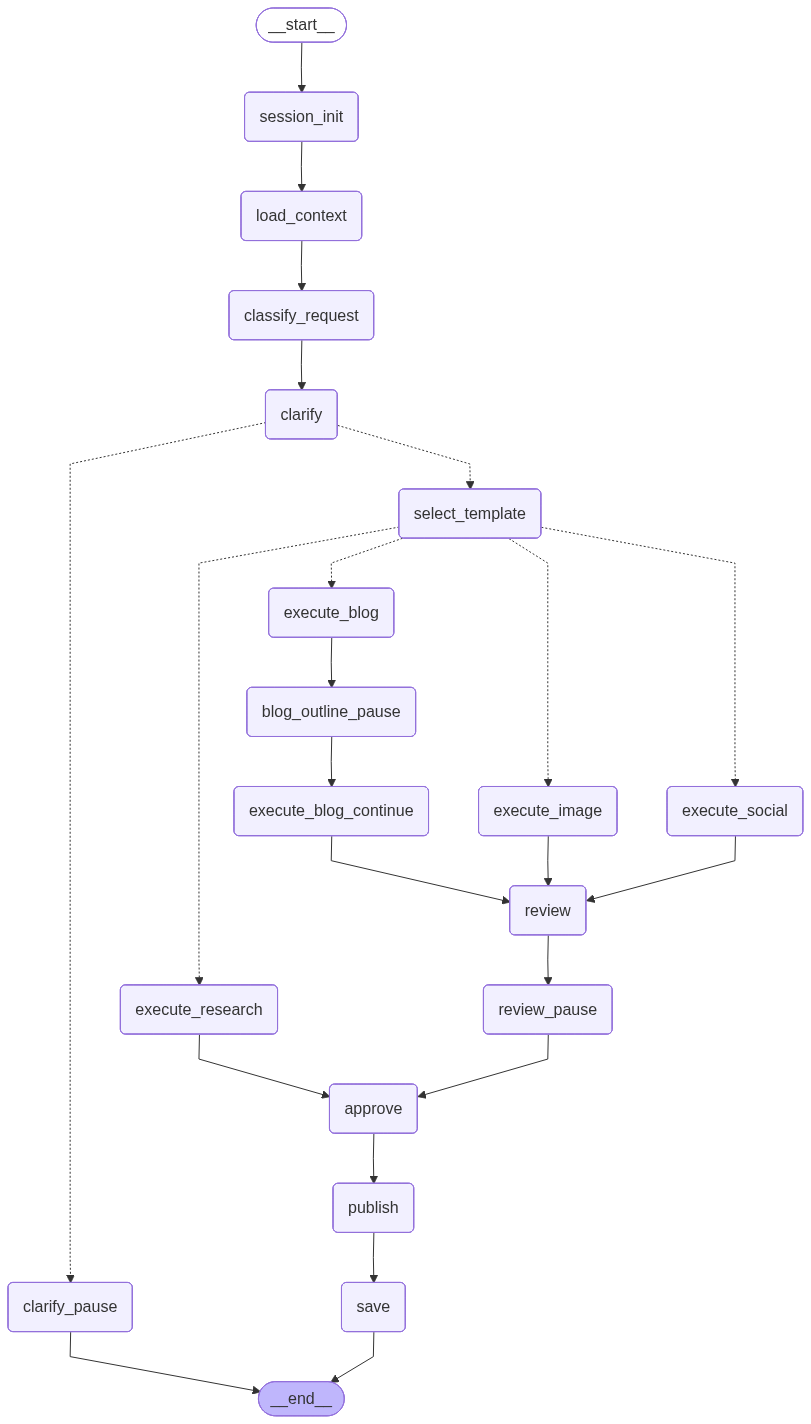

In [7]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(WorkflowState)

# ─ ADD ALL NODES ─
node_names = [
    "session_init", "load_context", "classify_request", "clarify", "clarify_pause",
    "select_template", "execute_social", "execute_blog", "blog_outline_pause",
    "execute_blog_continue", "execute_image", "execute_research",
    "review", "review_pause", "approve", "publish", "save"
]
for name in node_names:
    workflow.add_node(name, locals()[name])

# ─ MAIN FLOW ─
workflow.add_edge(START, "session_init")
workflow.add_edge("session_init", "load_context")
workflow.add_edge("load_context", "classify_request")
workflow.add_edge("classify_request", "clarify")

# ─ CONDITIONAL: CLARIFY ─
def route_clarify(state):
    if state["template"] == "blog" and len(state["request"]) < 50:
        return "clarify_pause"
    return "select_template"

workflow.add_conditional_edges(
    "clarify",
    route_clarify,
    {
        "clarify_pause": "clarify_pause",
        "select_template": "select_template"
    }
)

workflow.add_edge("clarify_pause", END)

# ─ CONDITIONAL: ROUTE TEMPLATE ─
# ⚠️ KHÔNG add_edge từ select_template ở đây
workflow.add_conditional_edges(
    "select_template",
    route_template,   # hàm này đã định nghĩa ở Cell 1, trả về tên node trực tiếp
    {
        "execute_social":   "execute_social",
        "execute_blog":     "execute_blog",
        "execute_image":    "execute_image",
        "execute_research": "execute_research"
    }
)

# ─ TEMPLATE → NEXT NODE ─
workflow.add_edge("execute_social",       "review")
workflow.add_edge("execute_blog",         "blog_outline_pause")
workflow.add_edge("execute_blog_continue","review")
workflow.add_edge("execute_image",        "review")
workflow.add_edge("execute_research",     "approve")

# ─ BLOG OUTLINE PAUSE ─
workflow.add_edge("blog_outline_pause", "execute_blog_continue")

# ─ REVIEW FLOW ─
workflow.add_edge("review",       "review_pause")
workflow.add_edge("review_pause", "approve")

# ─ PUBLISH FLOW ─
workflow.add_edge("approve",  "publish")
workflow.add_edge("publish",  "save")
workflow.add_edge("save",     END)

# ─ COMPILE ─
graph = workflow.compile()
print("✅ Cell 4: Graph compiled!")
print(f"📊 Total nodes: {len(graph.nodes)}")

# ─ VISUALIZE ─
try:
    graph_image = graph.get_graph().draw_mermaid_png()
    from IPython.display import Image, display
    display(Image(graph_image))
except Exception as e:
    print(f"⚠️  Mermaid PNG error: {e}")
    print("\nMermaid text view:")
    print(graph.get_graph().draw_mermaid())

In [5]:
print("\n" + "="*60)
print("DEMO: SOCIAL POST with Groq")
print("="*60 + "\n")

initial_state = {
    "session_id": "", "workspace_id": "", "user_id": "",
    "request": "Create a viral social media post about AI marketing trends in 2026",
    "template": None, "clarification": [], "context": {}, "retrieved_docs": [],
    "outline": None, "draft": None, "images": [], "edits": None,
    "approved": False, "publish_status": "pending", "usage": {}, "error": None
}

final_state = initial_state.copy()

for output in graph.stream(final_state):
    if output:
        node_name = list(output.keys())[0]
        state_result = output[node_name]
        if state_result is not None:
            final_state = state_result

print("\n" + "="*60)
print("✅ WORKFLOW COMPLETED")
print("="*60)
print(f"\n📝 FINAL DRAFT:\n{final_state['draft']}")
print(f"\n📊 USAGE: {final_state['usage']}")
print(f"✅ APPROVED: {final_state['approved']}")
print(f"📤 STATUS: {final_state['publish_status']}")
print("="*60)


DEMO: SOCIAL POST with Groq

📌 SESSION_INIT: 74f43df3
📂 LOAD_CONTEXT: ✅
🔍 CLASSIFY_REQUEST: SOCIAL
✅ CLARIFY: No clarification needed
📋 SELECT: SOCIAL
🟩 [SOCIAL]...
  ✅ Done
🔍 REVIEW MODE
📄 "Get ready for the future of marketing! In 2026, AI will dominate with trends like AI-powered conten...
⏸️  PAUSED — Waiting for approval...
✅ APPROVED
📤 PUBLISH: Pushing...
✅ Published
💾 SAVE: Persisting...
✅ Session 74f43df3 saved

✅ WORKFLOW COMPLETED

📝 FINAL DRAFT:
"Get ready for the future of marketing! In 2026, AI will dominate with trends like AI-powered content creation, chatbots on steroids & hyper-personalization. Are you ready to level up your marketing game? #AIMarketing #MarketingTrends #FutureOfMarketing"

📊 USAGE: {'tokens': 150, 'cost': 0.0}
✅ APPROVED: True
📤 STATUS: published


In [6]:
# Demo 1: SOCIAL
print("="*60)
print("DEMO 1: SOCIAL POST")
print("="*60)

initial_state = {
    "session_id": "",
    "workspace_id": "",
    "user_id": "",
    "request": "Create a social media post about AI marketing",
    "template": None,
    "clarification": [],
    "context": {},
    "retrieved_docs": [],
    "outline": None,
    "draft": None,
    "images": [],
    "edits": None,
    "approved": False,
    "publish_status": "pending",
    "usage": {},
    "error": None
}

for output in graph.stream(initial_state):
    if output:
        node_name, result = next(iter(output.items()))
        if "draft" in result and result["draft"]:
            print(f"\n📄 Final Draft:\n{result['draft']}\n")

print("\n" + "="*60)

DEMO 1: SOCIAL POST
📌 SESSION_INIT: 980d38f0
📂 LOAD_CONTEXT: ✅
🔍 CLASSIFY_REQUEST: SOCIAL
✅ CLARIFY: No clarification needed
📋 SELECT: SOCIAL
🟩 [SOCIAL]...
⚠️  Groq error: Error code: 400 - {'error': {'message': 'The model `llama-3.1-70b-versatile` has been decommissioned
  ✅ Done

📄 Final Draft:
[Mock response]

🔍 REVIEW MODE
📄 Draft: [Mock response]...
⏸️  PAUSED — Waiting for approval...

📄 Final Draft:
[Mock response]


📄 Final Draft:
[Mock response]

✅ APPROVED

📄 Final Draft:
[Mock response]

📤 PUBLISH: Pushing...
✅ Published

📄 Final Draft:
[Mock response]

💾 SAVE: Persisting...
✅ Session 980d38f0 saved

📄 Final Draft:
[Mock response]




In [10]:
print("\n" + "="*60)
print("DEMO 2: BLOG (with outline approval)")
print("="*60 + "\n")

blog_state = {
    "session_id": "", "workspace_id": "", "user_id": "",
    "request": "Write a detailed blog about AI marketing strategies for enterprise",
    "template": None, "clarification": [], "context": {}, "retrieved_docs": [],
    "outline": None, "draft": None, "images": [], "edits": None,
    "approved": False, "publish_status": "pending", "usage": {}, "error": None
}

final_state = blog_state.copy()
paused_at = None

# ─ Run until pause at blog_outline_pause ─
for output in graph.stream(final_state):
    if output:
        node_name = list(output.keys())[0]
        state_result = output[node_name]
        if state_result is not None:
            final_state = state_result
            if node_name == "blog_outline_pause":
                paused_at = "blog_outline_pause"
                print(f"⏸️  PAUSED at BLOG OUTLINE")
                print(f"\n📑 Generated Outline (first 300 chars):\n{final_state['outline'][:300]}...\n")

if paused_at == "blog_outline_pause":
    print("👤 User approves outline...\n")
    
    # ─ Resume: Continue workflow manually ─
    final_state = execute_blog_continue(final_state)
    
    # ─ Now go to review (use review_pause instead of review to avoid Command) ─
    print("🔍 REVIEW MODE")
    preview = final_state["draft"][:100] if final_state["draft"] else "No draft"
    print(f"📄 {preview}...")
    print("⏸️  PAUSED — Waiting for approval...\n")
    
    print("👤 User approves draft...\n")
    
    # ─ Approve → Publish → Save ─
    final_state = approve(final_state)
    final_state = publish(final_state)
    final_state = save(final_state)

print("\n" + "="*60)
print("✅ DEMO 2 COMPLETED")
print("="*60)
print(f"\n📑 OUTLINE:\n{final_state['outline'][:200]}...\n")
print(f"📝 DRAFT:\n{final_state['draft'][:200]}...\n")
print(f"📊 USAGE: {final_state['usage']}")
print(f"✅ APPROVED: {final_state['approved']}")
print(f"📤 STATUS: {final_state['publish_status']}")
print("="*60)


DEMO 2: BLOG (with outline approval)

📌 SESSION_INIT: 2077794c
📂 LOAD_CONTEXT: ✅
🔍 CLASSIFY_REQUEST: BLOG
✅ CLARIFY: No clarification needed
📋 SELECT: BLOG
🟦 [BLOG]...
  ⏸️  Outline ready, waiting for approval...
⏸️  PAUSED: User approves outline
⏸️  PAUSED at BLOG OUTLINE

📑 Generated Outline (first 300 chars):
Here is a detailed blog outline on AI marketing strategies for enterprise:

**Title:** "Revolutionizing Enterprise Marketing: A Comprehensive Guide to AI Marketing Strategies"

**I. Introduction**

* Brief overview of AI in marketing and its growing importance
* Explanation of the benefits of AI in ...

👤 User approves outline...

🟦 [BLOG] Resume...
  ✅ Done
🔍 REVIEW MODE
📄 **Revolutionizing Enterprise Marketing: A Comprehensive Guide to AI Marketing Strategies**

The worl...
⏸️  PAUSED — Waiting for approval...

👤 User approves draft...

✅ APPROVED
📤 PUBLISH: Pushing...
✅ Published
💾 SAVE: Persisting...
✅ Session 2077794c saved

✅ DEMO 2 COMPLETED

📑 OUTLINE:
Here is a detail

In [11]:
image_request = "Generate a futuristic AI dashboard image with holographic elements"
image_state = blog_state.copy()
image_state["request"] = image_request
image_state["template"] = "image"

final = image_state
for output in graph.stream(final):
    if output:
        final = list(output.values())[0] or final

print(f"🎯 IMAGE PROMPT:\n{final['images'][0]['prompt']}")

📌 SESSION_INIT: 2c982c0f
📂 LOAD_CONTEXT: ✅
🔍 CLASSIFY_REQUEST: IMAGE
✅ CLARIFY: No clarification needed
📋 SELECT: IMAGE
🟨 [IMAGE]...
  ✅ Done
🔍 REVIEW MODE
📄 Prompt: Here is a descriptive prompt for generating a futuristic AI dashboard image with holographic...
⏸️  PAUSED — Waiting for approval...
✅ APPROVED
📤 PUBLISH: Pushing...
✅ Published
💾 SAVE: Persisting...
✅ Session 2c982c0f saved
🎯 IMAGE PROMPT:
Here is a descriptive prompt for generating a futuristic AI dashboard image with holographic elements:

**Image Prompt:**

Create a futuristic AI dashboard image that showcases a sleek, high-tech interface with holographic elements. The dashboard is set in a futuristic, minimalist environment with a dark, metallic background that reflects the light of the holographic projections.

**Central Holographic Display:**
At the center of the dashboard, a large, spherical holographic display floats in mid-air, projecting a 360-degree visualization of a futuristic cityscape. The cityscape is repr